In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Employers_data.csv")
df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [3]:
df=df.drop(['Employee_ID','Name','Location'],axis=1)

In [4]:
df.isna().sum()

Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Salary              0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               10000 non-null  int64 
 1   Gender            10000 non-null  object
 2   Department        10000 non-null  object
 3   Job_Title         10000 non-null  object
 4   Experience_Years  10000 non-null  int64 
 5   Education_Level   10000 non-null  object
 6   Salary            10000 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 547.0+ KB


In [6]:
df=pd.get_dummies(df,columns=['Gender','Department','Job_Title','Education_Level'],dtype=int)

In [7]:
df.head()

,Age,Experience_Years,Salary,Gender_Female,Gender_Male,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Product,Department_Sales,Job_Title_Analyst,Job_Title_Engineer,Job_Title_Executive,Job_Title_Intern,Job_Title_Manager,Education_Level_Bachelor,Education_Level_Master,Education_Level_PhD
0,24,1,90000,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
1,56,33,195000,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0
2,21,1,35000,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0
3,30,9,75000,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0
4,25,2,70000,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0


In [8]:
x=df.drop("Salary",axis=1)
y=df['Salary']

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
import xgboost as xgb
from sklearn.metrics import r2_score

# n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42
model=xgb.XGBRFRegressor()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(r2_score(y_test,y_pred)*100)

99.11723136901855


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

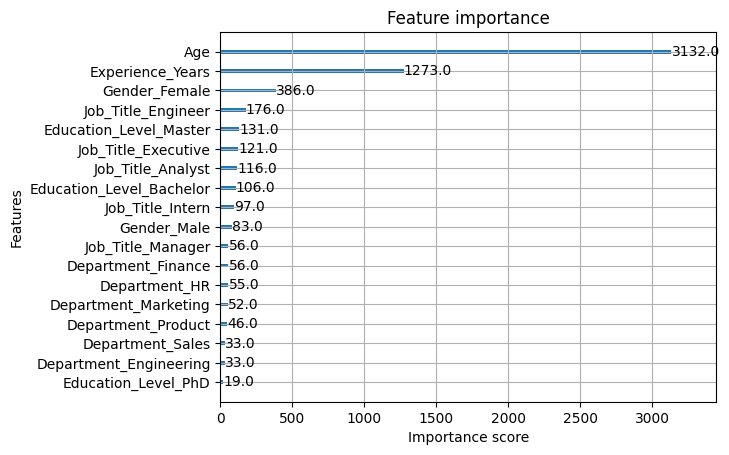

In [11]:
xgb.plot_importance(model)